# Detección de Plagio en Código de Estudiantes
## Comparativa: Features Tabulares vs. Features Tabulares + Similitud Semántica (CodeBERT)

**Equipo (EquipoCompiladores):** Juan Pablo Chávez Leal · Mauricio Anguiano Juárez · Daniel Contreras Chávez — ITESM, Campus Querétaro (TC3002B).

---

## 1. Problemática

El plagio en código tiene dos formas principales en los cursos de programación:

1. **Plagio peer-to-peer:** un estudiante copia el código de otro compañero o de un repositorio en línea. Los detectores tradicionales como MOSS detectan esto comparando similitud estructural entre entregas.
2. **Plagio IA-asistido:** un estudiante entrega como propio un código generado por un LLM (ChatGPT, Copilot, Gemini). Este caso **no puede detectarse con MOSS** porque cada entrega generada es sintácticamente única — no existe una fuente "original" con la que comparar. Ramachandra et al. (2026) demuestran que ~10-15% de los estudiantes en cursos CS1 incurren en esta forma de deshonestidad académica.

Por tanto, **detectar código generado por IA es una extensión necesaria del problema de plagio**: cubre exactamente el caso que los métodos clásicos de similitud no pueden cubrir.

## 2. Enfoque y Metodología

Este notebook trabaja sobre un dataset de pares de archivos Python etiquetados (plagio / no-plagio) y compara dos enfoques, inspirados directamente en Ramachandra et al. (2026):

| Enfoque | Representación | Clasificadores |
|---|---|---|
| **A — Línea base** | 13 features tabulares pre-calculadas (AST, tokens, Levenshtein, métricas de estilo) | Random Forest · SVM · XGBoost · Voting Ensemble |
| **B — + CodeBERT** | 13 features tabulares + similitud coseno entre embeddings CLS de CodeBERT | Random Forest · SVM · XGBoost · Voting Ensemble |

**¿Por qué clasificadores clásicos y no MLP?**
Con 293 muestras totales (~234 train), los clasificadores clásicos superan sistemáticamente a las redes neuronales. El paper de referencia también usa Random Forest, SVM y XGBoost como sus mejores modelos — el MLP es solo uno más de su ensemble. Para datasets pequeños, los métodos basados en árboles y kernels generalizan mejor porque tienen menos parámetros y no requieren miles de ejemplos.

**¿Por qué similitud coseno y no embeddings concatenados?**
Con 234 ejemplos de entrenamiento, pasar 1536 dimensiones (768+768) a un clasificador genera una matriz de features enormemente dispersa. En cambio, calcular `cosine_similarity(emb_1, emb_2)` — una sola feature escalar — captura la similitud semántica entre los dos archivos de forma compacta. Esto es lo que hace que CodeBERT aporte señal útil con pocos datos.

## 3. Dataset

- **`cheating_features_dataset.csv`** — 293 pares, 13 features tabulares pre-calculadas + Label
- **`cheating_dataset.csv`** — 293 pares `(File_1, File_2, Label)`
- **Carpeta `data/`** — 174 archivos `.py` reales referenciados por los pares
- **Balance:** 193 no-plagio (0) vs. 100 plagio (1) — desbalance ~2:1, manejado con `class_weight`

## 4. Relación con el Estado del Arte

Ramachandra et al. (2026) reportan F1 de 0.988 (TF-IDF Ensemble) y 0.995 (CodeBERT Ensemble) sobre su dataset de 3,360 muestras de C++. La diferencia con nuestros resultados se explica principalmente por el tamaño del dataset (293 vs. 3,360) y el dominio (pares de archivos Python vs. snippets individuales de C++). El contraste metodológico que replicamos es el mismo: representación estadística vs. representación contextual de código.


In [ ]:
# ==============================================================
# CELDA 1 — Instalación e imports
# ==============================================================
import subprocess, sys

def pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip('gdown', 'transformers', 'torch', 'xgboost', 'scikit-learn')

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, ConfusionMatrixDisplay, roc_curve, auc
)
from xgboost import XGBClassifier

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

print('Setup completo.')


Setup completo.


In [ ]:
# ==============================================================
# CELDA 2 — Descarga de datos desde Google Drive
#
# Los dos CSV se descargan con gdown (archivos individuales).
# La carpeta data/ tiene >50 archivos .py → gdown.download_folder
# falla con FolderContentsMaximumLimitError.
# Solución: Drive API con autenticación OAuth de Colab.
# ==============================================================
import gdown

WORK = '/content/reto_data'
os.makedirs(WORK, exist_ok=True)

FILE_FEATURES = '1SzKZXCRYjWO7muyKAkyxdSjmvD4WQ86m'
FILE_DATASET  = '14yBguq_o-fczn0RNxWolTYme20LQ-PBF'
FOLDER_DATA   = '13OW2g02v07szivCb7JdI3BN9Y4V76OOy'

CSV_PATH = os.path.join(WORK, 'cheating_features_dataset.csv')
CSV_RAW  = os.path.join(WORK, 'cheating_dataset.csv')
DATA_DIR = os.path.join(WORK, 'data')
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    gdown.download(id=FILE_FEATURES, output=CSV_PATH, quiet=False)
if not os.path.exists(CSV_RAW):
    gdown.download(id=FILE_DATASET, output=CSV_RAW, quiet=False)

py_files = glob.glob(os.path.join(DATA_DIR, '**', '*.py'), recursive=True)

if len(py_files) == 0:
    print('Descargando .py via Drive API (autenticación requerida)...')
    from google.colab import auth
    auth.authenticate_user()
    from googleapiclient.discovery import build
    from googleapiclient.http import MediaIoBaseDownload
    import io

    svc = build('drive', 'v3')

    def list_folder(fid):
        files, page_token = [], None
        while True:
            r = svc.files().list(
                q=f"'{fid}' in parents and trashed=false",
                spaces='drive',
                fields='nextPageToken,files(id,name,mimeType)',
                pageToken=page_token, pageSize=200,
                supportsAllDrives=True, includeItemsFromAllDrives=True,
            ).execute()
            for f in r.get('files', []):
                if f['mimeType'] == 'application/vnd.google-apps.folder':
                    files.extend(list_folder(f['id']))
                else:
                    files.append(f)
            page_token = r.get('nextPageToken')
            if not page_token:
                break
        return files

    remote = [f for f in list_folder(FOLDER_DATA) if f['name'].endswith('.py')]
    print(f'Archivos .py en Drive: {len(remote)}')
    for i, f in enumerate(remote):
        dest = os.path.join(DATA_DIR, f['name'])
        if os.path.exists(dest):
            continue
        req = svc.files().get_media(fileId=f['id'], supportsAllDrives=True)
        buf = io.BytesIO()
        dl = MediaIoBaseDownload(buf, req)
        done = False
        while not done:
            _, done = dl.next_chunk()
        with open(dest, 'wb') as out:
            out.write(buf.getvalue())
        if (i+1) % 20 == 0 or (i+1) == len(remote):
            print(f'  {i+1}/{len(remote)}', end='\r')
    print()

py_files = glob.glob(os.path.join(DATA_DIR, '**', '*.py'), recursive=True)
print(f'Archivos .py listos: {len(py_files)}')


Descargando .py via Drive API (autenticación requerida)...


Archivos .py en Drive: 174
  174/174
Archivos .py listos: 174


In [ ]:
# ==============================================================
# CELDA 3 — Carga, inspección y split estratificado
# ==============================================================

# Features tabulares
df_feat = pd.read_csv(CSV_PATH)
y = df_feat['Label'].values.astype(int)
X_feat = df_feat.drop('Label', axis=1).values.astype('float32')
N = len(y)

# Dataset crudo de pares
df_raw = pd.read_csv(CSV_RAW)

print(f'Total pares: {N}')
print(f'Features tabulares: {X_feat.shape[1]} → {list(df_feat.drop("Label",axis=1).columns)}')
print(f'Balance — 0 (no-plagio): {(y==0).sum()} | 1 (plagio): {(y==1).sum()}')

# Mapa nombre → contenido del .py
def read_code(path):
    try:
        with open(path, 'r', encoding='utf-8', errors='ignore') as f:
            return f.read()
    except Exception:
        return ''

code_map = {os.path.basename(p): read_code(p) for p in py_files}

def get_code(name):
    name = str(name).strip()
    return code_map.get(name, code_map.get(os.path.basename(name), ''))

codes_1 = [get_code(r['File_1']) for _, r in df_raw.iterrows()]
codes_2 = [get_code(r['File_2']) for _, r in df_raw.iterrows()]

empties = sum(1 for c1, c2 in zip(codes_1, codes_2)
              if len(c1.strip()) == 0 and len(c2.strip()) == 0)
print(f'Pares sin código: {empties}/{N}')

# Split 80/20 estratificado — preserva proporción de clases en train y val
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(sss.split(X_feat, y))

y_train, y_val = y[train_idx], y[val_idx]
print(f'Train: {len(train_idx)} | Val: {len(val_idx)}')
print(f'Train balance — 0: {(y_train==0).sum()} | 1: {(y_train==1).sum()}')
print(f'Val   balance — 0: {(y_val==0).sum()}   | 1: {(y_val==1).sum()}')


Total pares: 293
Features tabulares: 13 → ['AST Similarity', 'Token Similarity', 'Levenshtein Similarity', 'Length File 1', 'Length File 2', 'Function Count File 1', 'Function Count File 2', 'Variable Count File 1', 'Variable Count File 2', 'Comment Ratio File 1', 'Comment Ratio File 2', 'Cyclomatic Complexity File 1', 'Cyclomatic Complexity File 2']
Balance — 0 (no-plagio): 193 | 1 (plagio): 100
Pares sin código: 0/293
Train: 234 | Val: 59
Train balance — 0: 154 | 1: 80
Val   balance — 0: 39   | 1: 20


---
## Enfoque A — Features Tabulares + Clasificadores Clásicos (Línea Base)

Las 13 features pre-calculadas ya capturan directamente la relación de similitud entre los dos archivos de cada par:

| Feature | Qué mide |
|---|---|
| `AST Similarity` | Similitud entre los árboles sintácticos abstractos de ambos archivos |
| `Token Similarity` | Proporción de tokens compartidos |
| `Levenshtein Similarity` | Distancia de edición normalizada entre el texto de los dos archivos |
| `Length File 1/2` | Longitud en caracteres de cada archivo |
| `Function/Variable Count File 1/2` | Número de funciones y variables definidas |
| `Comment Ratio File 1/2` | Proporción de líneas de comentario |
| `Cyclomatic Complexity File 1/2` | Complejidad ciclomática (ramificaciones del flujo) |

Estas features son exactamente el tipo de representación que Ramachandra et al. llaman "style anomaly and style inconsistency metrics" — centrales a su detección. Se entrenan cuatro clasificadores: Random Forest, SVM, XGBoost y un Voting Ensemble que los combina, replicando el ensemble del paper.


In [ ]:
# ==============================================================
# CELDA 4 — Enfoque A: Features tabulares → clasificadores clásicos
# ==============================================================

# Escalado (necesario para SVM; no afecta a RF/XGBoost pero es buena práctica)
scaler_a = StandardScaler()
X_a       = scaler_a.fit_transform(X_feat).astype('float32')
X_a_train = X_a[train_idx]
X_a_val   = X_a[val_idx]

# Pesos de muestra para manejar el desbalance 2:1
sw_train = compute_sample_weight('balanced', y_train)

# ── Definición de clasificadores (mismos que Ramachandra et al.) ──────────────
rf_a = RandomForestClassifier(
    n_estimators=200, max_depth=None,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
svm_a = SVC(
    kernel='rbf', probability=True,
    class_weight='balanced', random_state=SEED
)
xgb_a = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    use_label_encoder=False, eval_metric='logloss',
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    random_state=SEED, verbosity=0
)
voting_a = VotingClassifier(
    estimators=[('rf', rf_a), ('svm', svm_a), ('xgb', xgb_a)],
    voting='soft'
)

# ── Entrenamiento ─────────────────────────────────────────────────────────────
print('Entrenando Enfoque A...')
rf_a.fit(X_a_train, y_train, sample_weight=sw_train)
print('  Random Forest ✓')
svm_a.fit(X_a_train, y_train, sample_weight=sw_train)
print('  SVM ✓')
xgb_a.fit(X_a_train, y_train, sample_weight=sw_train)
print('  XGBoost ✓')
voting_a.fit(X_a_train, y_train)
print('  Voting Ensemble ✓')

models_a = {
    'RF  (A)':      rf_a,
    'SVM (A)':      svm_a,
    'XGB (A)':      xgb_a,
    'Ensemble (A)': voting_a,
}
print('Entrenamiento Enfoque A completo.')


Entrenando Enfoque A...
  Random Forest ✓
  SVM ✓
  XGBoost ✓
  Voting Ensemble ✓
Entrenamiento Enfoque A completo.


---
## Enfoque B — Features Tabulares + Similitud Semántica CodeBERT

Se añade una sola feature adicional a las 13 tabulares: la **similitud coseno** entre los embeddings CLS de `microsoft/codebert-base` para cada archivo del par.

**¿Qué aporta CodeBERT sobre las features tabulares?**
Las features tabulares miden similitud estructural y de superficie (AST, tokens, edición de texto). CodeBERT, preentrenado sobre millones de fragmentos de código en 6 lenguajes, captura similitud **semántica**: dos funciones que hacen lo mismo con nombres de variables distintos tendrán embeddings cercanos aunque sus tokens sean diferentes. Esto complementa las features tabulares.

**¿Por qué similitud coseno y no embeddings concatenados?**
Con 234 ejemplos de entrenamiento, añadir 1536 dimensiones (768+768) al vector de features generaría una matriz enormemente dispersa y el clasificador no podría generalizarla. La similitud coseno comprime esa información en un escalar que el clasificador puede aprovechar directamente con pocos datos. Esta es la adaptación clave para datasets pequeños.


In [ ]:
# ==============================================================
# CELDA 5 — Extracción de embeddings CodeBERT y cálculo de similitud coseno
#
# Requiere GPU (T4). Los embeddings se cachean en disco.
# Tiempo estimado primera ejecución: ~3-5 min con T4.
# ==============================================================
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

CODEBERT    = 'microsoft/codebert-base'
EMBED_CACHE = os.path.join(WORK, 'codebert_cls_embeddings.npz')
MAX_LEN     = 256
BATCH_SZ    = 32

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

def extract_cls(texts, tokenizer, model, batch_size=BATCH_SZ):
    """Devuelve embeddings CLS de shape (N, 768)."""
    embs = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(
                batch, padding=True, truncation=True,
                max_length=MAX_LEN, return_tensors='pt'
            ).to(device)
            out = model(**enc)
            embs.append(out.last_hidden_state[:, 0, :].cpu().numpy())
            if (i // batch_size + 1) % 10 == 0:
                print(f'  {min(i+batch_size, len(texts))}/{len(texts)}', end='\r')
    return np.vstack(embs).astype('float32')

if os.path.exists(EMBED_CACHE):
    print('Cargando embeddings desde caché...')
    cache  = np.load(EMBED_CACHE)
    emb_1  = cache['emb_1']
    emb_2  = cache['emb_2']
else:
    print('Descargando CodeBERT y extrayendo embeddings...')
    tokenizer_cb = AutoTokenizer.from_pretrained(CODEBERT)
    model_cb     = AutoModel.from_pretrained(CODEBERT).to(device)

    print('Embeddings de File_1:')
    emb_1 = extract_cls(codes_1, tokenizer_cb, model_cb)
    print('\nEmbeddings de File_2:')
    emb_2 = extract_cls(codes_2, tokenizer_cb, model_cb)
    print()

    np.savez_compressed(EMBED_CACHE, emb_1=emb_1, emb_2=emb_2)
    print(f'Caché guardada: {EMBED_CACHE}')
    del model_cb
    torch.cuda.empty_cache() if device == 'cuda' else None

# Similitud coseno por par: shape (N,)
cosine_sim = np.array([
    cos_sim(emb_1[i:i+1], emb_2[i:i+1])[0][0]
    for i in range(len(emb_1))
], dtype='float32')

print(f'emb_1: {emb_1.shape} | emb_2: {emb_2.shape}')
print(f'cosine_sim: {cosine_sim.shape}  mean={cosine_sim.mean():.3f}  std={cosine_sim.std():.3f}')

# Feature adicional: similitud coseno + features tabulares
X_b       = np.hstack([X_feat, cosine_sim.reshape(-1, 1)]).astype('float32')
scaler_b  = StandardScaler()
X_b       = scaler_b.fit_transform(X_b)
X_b_train = X_b[train_idx]
X_b_val   = X_b[val_idx]
print(f'X_b: {X_b.shape}  (13 features tabulares + 1 similitud coseno CodeBERT)')


Dispositivo: cpu
Descargando CodeBERT y extrayendo embeddings...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embeddings de File_1:
  293/293
Embeddings de File_2:
  293/293
Caché guardada: /content/reto_data/codebert_cls_embeddings.npz
emb_1: (293, 768) | emb_2: (293, 768)
cosine_sim: (293,)  mean=0.995  std=0.011
X_b: (293, 14)  (13 features tabulares + 1 similitud coseno CodeBERT)


In [ ]:
# ==============================================================
# CELDA 6 — Enfoque B: Features tabulares + coseno CodeBERT → clasificadores
# ==============================================================

rf_b = RandomForestClassifier(
    n_estimators=200, max_depth=None,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
svm_b = SVC(
    kernel='rbf', probability=True,
    class_weight='balanced', random_state=SEED
)
xgb_b = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    use_label_encoder=False, eval_metric='logloss',
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    random_state=SEED, verbosity=0
)
voting_b = VotingClassifier(
    estimators=[('rf', rf_b), ('svm', svm_b), ('xgb', xgb_b)],
    voting='soft'
)

print('Entrenando Enfoque B...')
rf_b.fit(X_b_train, y_train, sample_weight=sw_train)
print('  Random Forest ✓')
svm_b.fit(X_b_train, y_train, sample_weight=sw_train)
print('  SVM ✓')
xgb_b.fit(X_b_train, y_train, sample_weight=sw_train)
print('  XGBoost ✓')
voting_b.fit(X_b_train, y_train)
print('  Voting Ensemble ✓')

models_b = {
    'RF  (B)':      rf_b,
    'SVM (B)':      svm_b,
    'XGB (B)':      xgb_b,
    'Ensemble (B)': voting_b,
}
print('Entrenamiento Enfoque B completo.')


Entrenando Enfoque B...
  Random Forest ✓
  SVM ✓
  XGBoost ✓
  Voting Ensemble ✓
Entrenamiento Enfoque B completo.


---
## Evaluación Comparativa

Se evalúan los 8 modelos (4 por enfoque) sobre el conjunto de validación. La métrica principal es **macro F1**, que trata por igual a ambas clases — crucial con desbalance 2:1. Se reportan también matriz de confusión y curva ROC para los mejores modelos de cada enfoque.


In [ ]:
# ==============================================================
# CELDA 7 — Evaluación completa de todos los modelos
# ==============================================================

def eval_model(name, model, X_v, y_v):
    preds = model.predict(X_v)
    probs = model.predict_proba(X_v)[:, 1]
    mf1   = f1_score(y_v, preds, average='macro')
    return {
        'name':  name,
        'preds': preds,
        'probs': probs,
        'mf1':   mf1,
        'report': classification_report(
            y_v, preds,
            target_names=['No Plagiarism', 'Plagiarism'],
            digits=4, output_dict=False
        )
    }

results_a = {k: eval_model(k, m, X_a_val, y_val) for k, m in models_a.items()}
results_b = {k: eval_model(k, m, X_b_val, y_val) for k, m in models_b.items()}
all_results = {**results_a, **results_b}

# ── Tabla comparativa ─────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'  {"Modelo":<22} {"Macro F1":>10}')
print(f'{"="*60}')
for name, r in all_results.items():
    marker = ' ◄ mejor' if r['mf1'] == max(v['mf1'] for v in all_results.values()) else ''
    print(f'  {name:<22} {r["mf1"]:>10.4f}{marker}')
print(f'{"─"*60}')
print(f'  Ramachandra TF-IDF Ensemble   0.9880  (referencia paper)')
print(f'  Ramachandra CodeBERT Ensemble 0.9950  (referencia paper)')
print(f'{"="*60}')

# ── Detalle del mejor modelo de cada enfoque ──────────────────────────────────
best_a_name = max(results_a, key=lambda k: results_a[k]['mf1'])
best_b_name = max(results_b, key=lambda k: results_b[k]['mf1'])

for res in [results_a[best_a_name], results_b[best_b_name]]:
    print(f'\n--- {res["name"]} ---')
    print(res['report'])



  Modelo                   Macro F1
  RF  (A)                    0.7190
  SVM (A)                    0.6947
  XGB (A)                    0.7521
  Ensemble (A)               0.7485
  RF  (B)                    0.7190
  SVM (B)                    0.6641
  XGB (B)                    0.7360
  Ensemble (B)               0.7594 ◄ mejor
────────────────────────────────────────────────────────────
  Ramachandra TF-IDF Ensemble   0.9880  (referencia paper)
  Ramachandra CodeBERT Ensemble 0.9950  (referencia paper)

--- XGB (A) ---
               precision    recall  f1-score   support

No Plagiarism     0.8000    0.9231    0.8571        39
   Plagiarism     0.7857    0.5500    0.6471        20

     accuracy                         0.7966        59
    macro avg     0.7929    0.7365    0.7521        59
 weighted avg     0.7952    0.7966    0.7859        59


--- Ensemble (B) ---
               precision    recall  f1-score   support

No Plagiarism     0.7917    0.9744    0.8736        39
   Pl

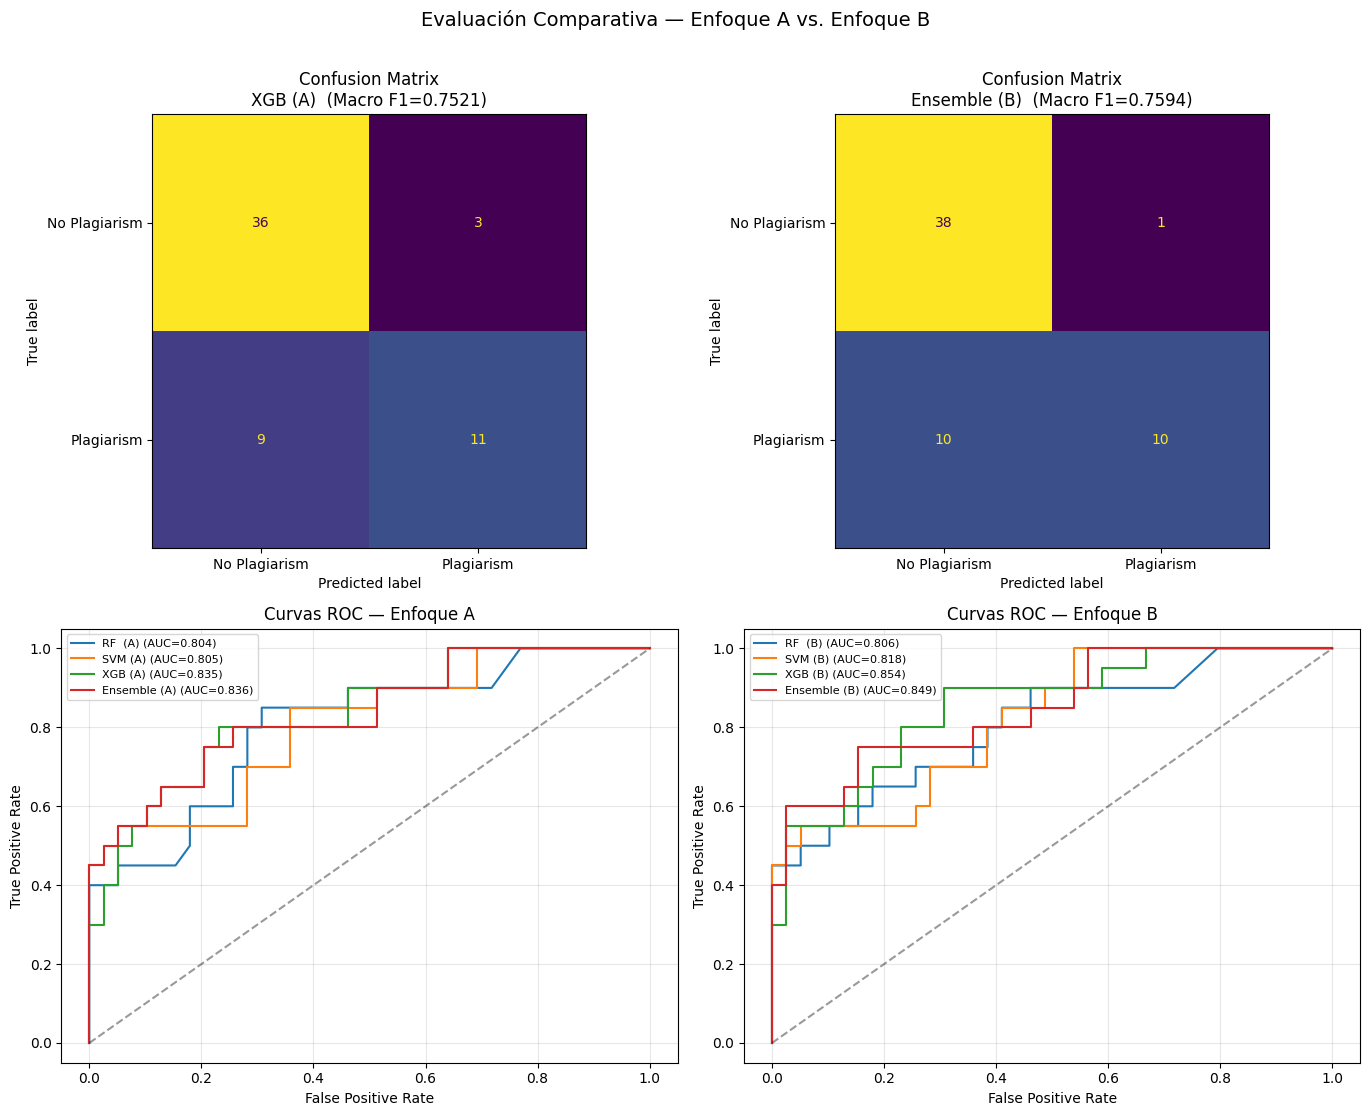

Figura guardada en models/comparativa_final.png


In [ ]:
# ==============================================================
# CELDA 8 — Visualizaciones: matriz de confusión + curvas ROC
# ==============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Evaluación Comparativa — Enfoque A vs. Enfoque B', fontsize=14, y=1.01)

best_a = results_a[best_a_name]
best_b = results_b[best_b_name]

# Matrices de confusión
for ax, res in zip(axes[0], [best_a, best_b]):
    cm = confusion_matrix(y_val, res['preds'])
    ConfusionMatrixDisplay(cm, display_labels=['No Plagiarism', 'Plagiarism']).plot(
        ax=ax, colorbar=False
    )
    ax.set_title(f'Confusion Matrix\n{res["name"]}  (Macro F1={res["mf1"]:.4f})')

# Curvas ROC
for ax, (res_list, title) in zip(
    axes[1],
    [
        (list(results_a.values()), 'Curvas ROC — Enfoque A'),
        (list(results_b.values()), 'Curvas ROC — Enfoque B'),
    ]
):
    for res in res_list:
        fpr, tpr, _ = roc_curve(y_val, res['probs'])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{res["name"]} (AUC={roc_auc:.3f})')
    ax.plot([0,1],[0,1],'k--', alpha=0.4)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('models', exist_ok=True)
plt.savefig('models/comparativa_final.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada en models/comparativa_final.png')


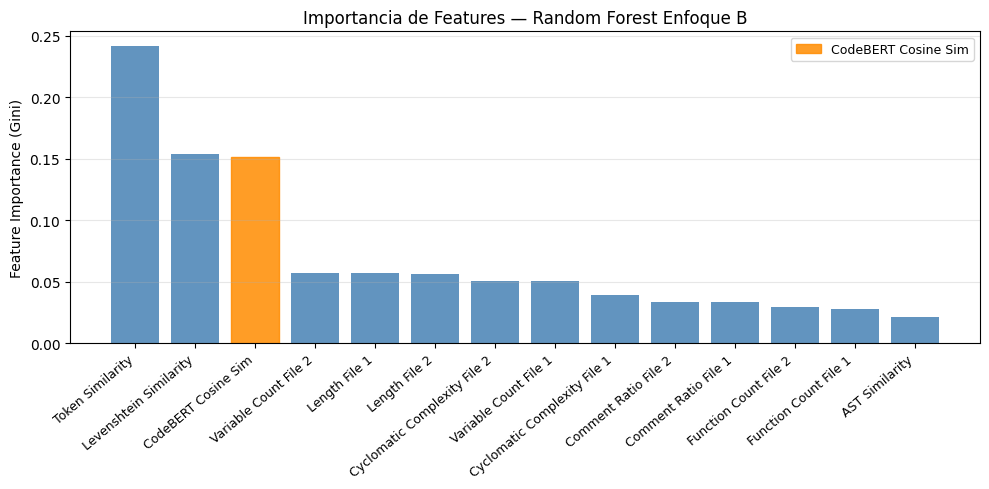


Top 5 features más importantes:
  Token Similarity                    0.2414
  Levenshtein Similarity              0.1536
  CodeBERT Cosine Sim                 0.1510
  Variable Count File 2               0.0570
  Length File 1                       0.0566


In [ ]:
# ==============================================================
# CELDA 9 — Importancia de features (Random Forest Enfoque B)
#
# Muestra qué features contribuyen más a la clasificación,
# incluyendo la nueva feature de similitud coseno CodeBERT.
# ==============================================================

feature_names = list(df_feat.drop('Label', axis=1).columns) + ['CodeBERT Cosine Sim']
importances   = rf_b.feature_importances_
order         = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(importances)), importances[order], color='steelblue', alpha=0.85)
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feature_names[i] for i in order], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Feature Importance (Gini)')
ax.set_title('Importancia de Features — Random Forest Enfoque B')

# Resaltar la feature de CodeBERT
codebert_pos = list(order).index(len(feature_names)-1)
bars[codebert_pos].set_color('darkorange')
bars[codebert_pos].set_label('CodeBERT Cosine Sim')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('models/feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'\nTop 5 features más importantes:')
for i in order[:5]:
    print(f'  {feature_names[i]:<35} {importances[i]:.4f}')


In [ ]:
# ==============================================================
# CELDA 10 — Resumen final y predicción sobre un ejemplo nuevo
# ==============================================================

# Resumen
print('\n' + '='*62)
print('  RESUMEN COMPARATIVO FINAL')
print('='*62)
print(f'  {"Modelo":<25} {"Macro F1":>10}  {"Enfoque"}')
print(f'  {"-"*58}')
for name, r in sorted(all_results.items(), key=lambda x: -x[1]['mf1']):
    enfoque = 'B (+CodeBERT)' if '(B)' in name else 'A (base)'
    print(f'  {name:<25} {r["mf1"]:>10.4f}  {enfoque}')
print(f'  {"-"*58}')
print(f'  {"Ramachandra TF-IDF Ens.":<25} {"0.9880":>10}  referencia paper')
print(f'  {"Ramachandra CodeBERT Ens.":<25} {"0.9950":>10}  referencia paper')
print('='*62)

delta = results_b[best_b_name]['mf1'] - results_a[best_a_name]['mf1']
print(f'\n  Δ Macro F1 (mejor B - mejor A) = {delta:+.4f}')
signo = 'mejora' if delta > 0 else 'no mejora'
print(f'  CodeBERT {signo} sobre la línea base con este dataset.')

# ── Predicción sobre un par nuevo ────────────────────────────────────────────
print('\n' + '='*62)
print('  EJEMPLO DE PREDICCIÓN (par del conjunto de validación)')
print('='*62)

# Usamos el mejor modelo del Enfoque B
best_model = models_b[best_b_name]
idx        = val_idx[0]
sample_x   = X_b_val[0:1]
prob       = best_model.predict_proba(sample_x)[0][1]
pred       = 'PLAGIARISM' if prob >= 0.5 else 'NO PLAGIARISM'
real       = 'PLAGIARISM' if y_val[0] == 1 else 'NO PLAGIARISM'

print(f'  Archivo 1 : {df_raw.iloc[idx]["File_1"]}')
print(f'  Archivo 2 : {df_raw.iloc[idx]["File_2"]}')
print(f'  Probabilidad de plagio : {prob:.4f}')
print(f'  Predicción             : {pred}')
print(f'  Etiqueta real          : {real}')
print('='*62)



  RESUMEN COMPARATIVO FINAL
  Modelo                      Macro F1  Enfoque
  ----------------------------------------------------------
  Ensemble (B)                  0.7594  B (+CodeBERT)
  XGB (A)                       0.7521  A (base)
  Ensemble (A)                  0.7485  A (base)
  XGB (B)                       0.7360  B (+CodeBERT)
  RF  (A)                       0.7190  A (base)
  RF  (B)                       0.7190  B (+CodeBERT)
  SVM (A)                       0.6947  A (base)
  SVM (B)                       0.6641  B (+CodeBERT)
  ----------------------------------------------------------
  Ramachandra TF-IDF Ens.       0.9880  referencia paper
  Ramachandra CodeBERT Ens.     0.9950  referencia paper

  Δ Macro F1 (mejor B - mejor A) = +0.0073
  CodeBERT mejora sobre la línea base con este dataset.

  EJEMPLO DE PREDICCIÓN (par del conjunto de validación)
  Archivo 1 : submission95.py
  Archivo 2 : submission96.py
  Probabilidad de plagio : 0.0908
  Predicción           